<a href="https://colab.research.google.com/github/SUDEEPZ-RAM/Classification-of-speech-categories-from-1-bit-quantized-signals/blob/main/Classical%20Models/mfcc_ml_1bit_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Dump

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
numeric = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_numeric.csv"
)

command = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_command.csv"
)

read = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_read.csv"
)

conversation = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_conversation.csv"
)

print("Numeric:", numeric.shape)
print("Command:", command.shape)
print("Read:", read.shape)
print("Conversation:", conversation.shape)

Numeric: (3000, 99)
Command: (3000, 99)
Read: (3000, 99)
Conversation: (3000, 99)


In [ ]:
numeric["speech_type"] = "numeric"
command["speech_type"] = "command"
read["speech_type"] = "read"
conversation["speech_type"] = "conversational"

In [ ]:
df = pd.concat(
    [
        numeric,
        command,
        read,
        conversation
    ],
    ignore_index=True
)

print(df.shape)

print(df["speech_type"].value_counts())

(12000, 100)
speech_type
numeric           3000
command           3000
read              3000
conversational    3000
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()

df["target"] = le.fit_transform(
    df["speech_type"]
)

print(
    dict(
        zip(
            le.classes_,
            range(len(le.classes_))
        )
    )
)

{'command': 0, 'conversational': 1, 'numeric': 2, 'read': 3}


In [ ]:
remove_cols = []

for col in [
    "filepath",
    "filename",
    "speaker",
    "session",
    "command",
    "digit",
    "label",
    "speech_type",
    "target"
]:

    if col in df.columns:
        remove_cols.append(col)

X = df.drop(
    columns=remove_cols
)

y = df["target"]

print("Features Shape:", X.shape)

Features Shape: (12000, 98)


In [ ]:
# First split: 80 train, 20 temp

X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

# Split temp into validation and test

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (9600, 98)
Validation: (1200, 98)
Test: (1200, 98)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)

# 96 Features

In [ ]:
xgb = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='multi:softmax',

    num_class=4,

    random_state=42,

    eval_metric='mlogloss'
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=4, ...)

In [ ]:
xgb_train_pred = xgb.predict(X_train)

xgb_val_pred = xgb.predict(X_val)

xgb_test_pred = xgb.predict(X_test)

xgb_train_acc = accuracy_score(
    y_train,
    xgb_train_pred
)

xgb_val_acc = accuracy_score(
    y_val,
    xgb_val_pred
)

xgb_test_acc = accuracy_score(
    y_test,
    xgb_test_pred
)

print("Train Accuracy:", xgb_train_acc)
print("Validation Accuracy:", xgb_val_acc)
print("Test Accuracy:", xgb_test_acc)

Train Accuracy: 0.9978125
Validation Accuracy: 0.8166666666666667
Test Accuracy: 0.8458333333333333


In [ ]:
print(
    classification_report(
        y_test,
        xgb_test_pred,
        target_names=le.classes_
    )
)

                precision    recall  f1-score   support

       command       0.77      0.80      0.79       300
conversational       0.83      0.84      0.84       300
       numeric       0.98      0.97      0.98       300
          read       0.78      0.76      0.77       300

      accuracy                           0.84      1200
     macro avg       0.84      0.84      0.84      1200
  weighted avg       0.84      0.84      0.84      1200



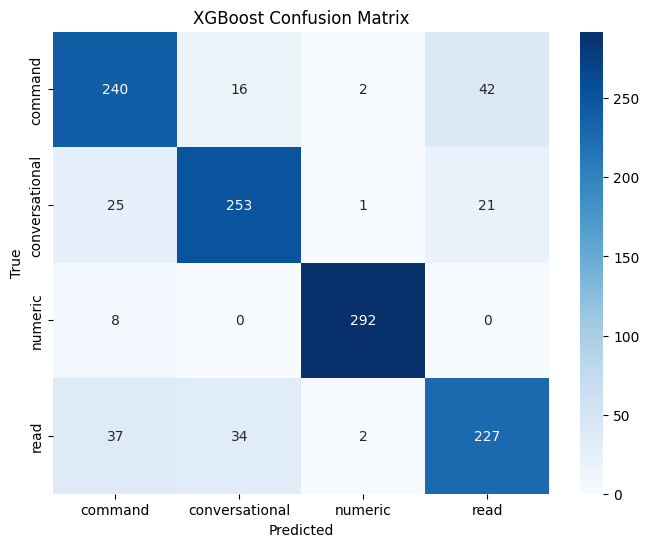

In [ ]:
cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [ ]:
import numpy as np

cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

class_acc = cm.diagonal() / cm.sum(axis=1)

for cls, acc in zip(
    le.classes_,
    class_acc
):
    print(
        f"{cls:15s} : {acc*100:.2f}%"
    )

command         : 80.00%
conversational  : 84.33%
numeric         : 97.33%
read            : 75.67%


In [ ]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
46,delta_1_mean,0.081017
6,max_pos_run,0.039600
9,max_neg_run,0.033131
29,mfcc_10_mean,0.025429
8,std_neg_run,0.025069
72,delta2_1_mean,0.023385
23,mfcc_4_mean,0.023372
28,mfcc_9_mean,0.022971
25,mfcc_6_mean,0.020781
27,mfcc_8_mean,0.019827


Best Model Evaluation
Accuracy           : 0.8433
Precision (Macro)  : 0.8438
Recall (Macro)     : 0.8433
F1 Score           : 0.8434
ROC-AUC            : 0.9670
Macro F1           : 0.8434
Equal Error Rate   : 0.0889


<Figure size 600x500 with 0 Axes>

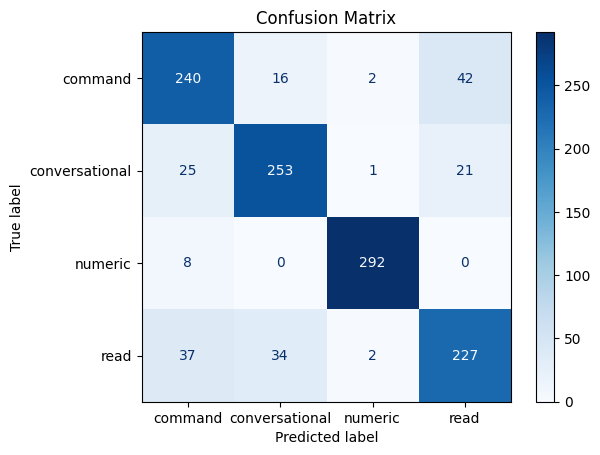

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Predictions
# -----------------------------
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)

# -----------------------------
# Metrics
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

macro_f1 = f1

# -----------------------------
# ROC-AUC
# -----------------------------
classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# -----------------------------
# Equal Error Rate (EER)
# -----------------------------
eer_list = []

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    fnr = 1 - tpr

    idx = np.nanargmin(np.abs(fpr - fnr))

    eer = (fpr[idx] + fnr[idx]) / 2

    eer_list.append(eer)

eer = np.mean(eer_list)

# -----------------------------
# Print Metrics
# -----------------------------
print("="*45)
print("Best Model Evaluation")
print("="*45)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision:.4f}")
print(f"Recall (Macro)     : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Equal Error Rate   : {eer:.4f}")

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

# 46 Features

In [ ]:
drop_cols = [
    col for col in df.columns
    if col.startswith("delta_") or col.startswith("delta2_")
]

df = df.drop(columns=drop_cols)

In [ ]:
print("Number of features:", len(df.columns) - 2)   # subtract label and class
print(df.shape)

Number of features: 47
(12000, 49)


In [ ]:
remove_cols = []

for col in [
    "filepath",
    "filename",
    "speaker",
    "session",
    "command",
    "digit",
    "label",
    "speech_type",
    "target"
]:

    if col in df.columns:
        remove_cols.append(col)

X = df.drop(
    columns=remove_cols
)

y = df["target"]

print("Features Shape:", X.shape)


Features Shape: (12000, 46)


In [ ]:
# First split: 80 train, 20 temp

X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

# Split temp into validation and test

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (9600, 46)
Validation: (1200, 46)
Test: (1200, 46)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)

In [ ]:
xgb = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='multi:softmax',

    num_class=4,

    random_state=42,

    eval_metric='mlogloss'
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=4, ...)

In [ ]:
xgb_train_pred = xgb.predict(X_train)

xgb_val_pred = xgb.predict(X_val)

xgb_test_pred = xgb.predict(X_test)

xgb_train_acc = accuracy_score(
    y_train,
    xgb_train_pred
)

xgb_val_acc = accuracy_score(
    y_val,
    xgb_val_pred
)

xgb_test_acc = accuracy_score(
    y_test,
    xgb_test_pred
)

print("Train Accuracy:", xgb_train_acc)
print("Validation Accuracy:", xgb_val_acc)
print("Test Accuracy:", xgb_test_acc)

Train Accuracy: 0.9930208333333334
Validation Accuracy: 0.8075
Test Accuracy: 0.8375


Best Model Evaluation
Accuracy           : 0.8375
Precision (Macro)  : 0.8367
Recall (Macro)     : 0.8375
F1 Score           : 0.8365
ROC-AUC            : 0.9631
Macro F1           : 0.8365
Equal Error Rate   : 0.0951


<Figure size 600x500 with 0 Axes>

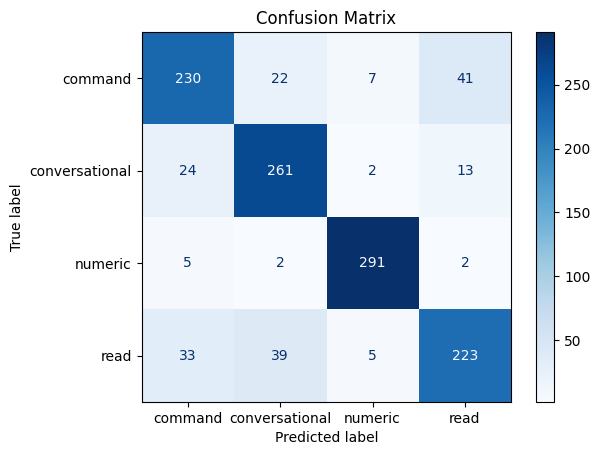

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Predictions
# -----------------------------
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)

# -----------------------------
# Metrics
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

macro_f1 = f1

# -----------------------------
# ROC-AUC
# -----------------------------
classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# -----------------------------
# Equal Error Rate (EER)
# -----------------------------
eer_list = []

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    fnr = 1 - tpr

    idx = np.nanargmin(np.abs(fpr - fnr))

    eer = (fpr[idx] + fnr[idx]) / 2

    eer_list.append(eer)

eer = np.mean(eer_list)

# -----------------------------
# Print Metrics
# -----------------------------
print("="*45)
print("Best Model Evaluation")
print("="*45)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision:.4f}")
print(f"Recall (Macro)     : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Equal Error Rate   : {eer:.4f}")

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

In [ ]:
import numpy as np

cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

class_acc = cm.diagonal() / cm.sum(axis=1)

for cls, acc in zip(
    le.classes_,
    class_acc
):
    print(
        f"{cls:15s} : {acc*100:.2f}%"
    )

command         : 76.67%
conversational  : 87.00%
numeric         : 97.00%
read            : 74.33%


# Hyper Paramter Tuning

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [3, 4, 5, 6, 8],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

    "min_child_weight": [1, 3, 5],

    "gamma": [0, 0.1, 0.3, 0.5],

    "reg_alpha": [0, 0.1, 0.5, 1],

    "reg_lambda": [1, 2, 5]
}

In [ ]:
xgb = XGBClassifier(

    objective="multi:softprob",

    num_class=4,

    eval_metric="mlogloss",

    random_state=42,

    tree_method="hist",

    n_jobs=-1
)

In [ ]:
random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_grid,

    n_iter=10,

    scoring="accuracy",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           num_class=4, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'reg_alpha': [0, 0.1, 0.5, 1],
                                        'reg_lambda': [1, 2, 5],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
print(random_search.best_params_)

print(random_search.best_score_)

{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
0.8302083333333333


In [ ]:
best_model = random_search.best_estimator_

In [ ]:
print("Train Accuracy :", best_model.score(X_train, y_train))

print("Validation Accuracy :", best_model.score(X_val, y_val))

print("Test Accuracy :", best_model.score(X_test, y_test))

Train Accuracy : 0.9658333333333333
Validation Accuracy : 0.8258333333333333
Test Accuracy : 0.8408333333333333


# Cross Model Inference-46

In [ ]:
import pandas as pd

# -------------------------
# 16-bit
# -------------------------

numeric16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_numeric.csv"
)

command16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_command.csv"
)

read16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_read.csv"
)

conversation16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_conversation.csv"
)

numeric16["class"] = 0
command16["class"] = 1
read16["class"] = 2
conversation16["class"] = 3

df16 = pd.concat(
    [
        numeric16,
        command16,
        read16,
        conversation16
    ],
    ignore_index=True
)

# -------------------------
# 1-bit
# -------------------------

numeric1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_numeric.csv"
)

command1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_command.csv"
)

read1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_read.csv"
)

conversation1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_conversation.csv"
)

numeric1["class"] = 0
command1["class"] = 1
read1["class"] = 2
conversation1["class"] = 3

df1 = pd.concat(
    [
        numeric1,
        command1,
        read1,
        conversation1
    ],
    ignore_index=True
)

print(df16.shape)
print(df1.shape)

(12000, 100)
(12000, 100)


In [ ]:
print(df16["class"].equals(df1["class"]))
print(df16["label"].equals(df1["label"]))

True
True


In [ ]:
# ==========================================================
# Create 46-feature dataset from 98-feature dataset
# ==========================================================

drop_cols = [
    c for c in df1.columns
    if c.startswith("delta_") or c.startswith("delta2_")
]

df1_46 = df1.drop(columns=drop_cols)
df16_46 = df16.drop(columns=drop_cols)

print("1-bit :", df1_46.shape)
print("16-bit:", df16_46.shape)

# ==========================================================
# Prepare Features
# ==========================================================

X1 = df1_46.drop(columns=["label", "class"])
y1 = df1_46["class"]

X16 = df16_46.drop(columns=["label", "class"])
y16 = df16_46["class"]

print("\nFeature Matrix Shapes")
print("1-bit :", X1.shape)
print("16-bit:", X16.shape)

1-bit : (12000, 48)
16-bit: (12000, 48)

Feature Matrix Shapes
1-bit : (12000, 46)
16-bit: (12000, 46)


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

indices = np.arange(len(df1))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=y1
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=y1.iloc[temp_idx]
)

In [ ]:
# -------- Train on 1-bit --------

X_train = X1.iloc[train_idx]
y_train = y1.iloc[train_idx]

# -------- Test on 16-bit --------

X_test = X16.iloc[test_idx]
y_test = y16.iloc[test_idx]

NameError: name 'X1' is not defined

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

acc = accuracy_score(y_test, pred)

print("="*60)
print("CROSS MODEL INFERENCE")
print("="*60)
print("Training Representation : 1-bit")
print("Testing Representation  : 16-bit")
print()
print("Features:46")
print()
print(f"Accuracy : {acc:.4f}")

CROSS MODEL INFERENCE
Training Representation : 1-bit
Testing Representation  : 16-bit

Features:46

Accuracy : 0.6067


# Cross Model Inference-98

In [ ]:
import pandas as pd

# -------------------------
# 16-bit
# -------------------------

numeric16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_numeric.csv"
)

command16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_command.csv"
)

read16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_read.csv"
)

conversation16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_conversation.csv"
)

numeric16["class"] = 0
command16["class"] = 1
read16["class"] = 2
conversation16["class"] = 3

df16 = pd.concat(
    [
        numeric16,
        command16,
        read16,
        conversation16
    ],
    ignore_index=True
)

# -------------------------
# 1-bit
# -------------------------

numeric1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_numeric.csv"
)

command1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_command.csv"
)

read1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_read.csv"
)

conversation1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_conversation.csv"
)

numeric1["class"] = 0
command1["class"] = 1
read1["class"] = 2
conversation1["class"] = 3

df1 = pd.concat(
    [
        numeric1,
        command1,
        read1,
        conversation1
    ],
    ignore_index=True
)

print(df16.shape)
print(df1.shape)

(12000, 100)
(12000, 100)


In [ ]:
X1 = df1.drop(columns=["label","class"])
y1 = df1["class"]

X16 = df16.drop(columns=["label","class"])
y16 = df16["class"]

print(X1.shape)
print(X16.shape)

(12000, 98)
(12000, 98)


In [ ]:
X_train = X1.iloc[train_idx]
y_train = y1.iloc[train_idx]

X_test = X16.iloc[test_idx]
y_test = y16.iloc[test_idx]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print("="*60)
print("98 Feature Cross Model Evaluation")
print("="*60)
print("Train : 1-bit")
print("Test  : 16-bit")
print("Features :", X_train.shape[1])
print("Accuracy :", accuracy_score(y_test, pred))

98 Feature Cross Model Evaluation
Train : 1-bit
Test  : 16-bit
Features : 98
Accuracy : 0.6466666666666666


# Only MFCC

In [ ]:
print(df.columns.tolist())

['mean_zcr', 'std_zcr', 'min_zcr', 'max_zcr', 'mean_pos_run', 'std_pos_run', 'max_pos_run', 'mean_neg_run', 'std_neg_run', 'max_neg_run', 'mean_autocorr_peak', 'std_autocorr_peak', 'mean_amdf_min', 'std_amdf_min', 'mean_hnr', 'std_hnr', 'mean_rhythm_change', 'std_rhythm_change', 'active_frame_ratio', 'longest_active_region', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean', 'mfcc_4_mean', 'mfcc_5_mean', 'mfcc_6_mean', 'mfcc_7_mean', 'mfcc_8_mean', 'mfcc_9_mean', 'mfcc_10_mean', 'mfcc_11_mean', 'mfcc_12_mean', 'mfcc_13_mean', 'mfcc_1_std', 'mfcc_2_std', 'mfcc_3_std', 'mfcc_4_std', 'mfcc_5_std', 'mfcc_6_std', 'mfcc_7_std', 'mfcc_8_std', 'mfcc_9_std', 'mfcc_10_std', 'mfcc_11_std', 'mfcc_12_std', 'mfcc_13_std', 'delta_1_mean', 'delta_2_mean', 'delta_3_mean', 'delta_4_mean', 'delta_5_mean', 'delta_6_mean', 'delta_7_mean', 'delta_8_mean', 'delta_9_mean', 'delta_10_mean', 'delta_11_mean', 'delta_12_mean', 'delta_13_mean', 'delta_1_std', 'delta_2_std', 'delta_3_std', 'delta_4_std', 'delta_5_std', '

In [ ]:
print(df["target"].value_counts())

target
2    3000
0    3000
3    3000
1    3000
Name: count, dtype: int64


In [ ]:
mfcc_cols = [col for col in df.columns if "mfcc" in col.lower()]

df_mfcc = df[mfcc_cols + ["target"]]

print(df_mfcc.shape)

(12000, 27)


In [ ]:
X = df_mfcc.drop(columns=["target"])
y = df_mfcc["target"]

print(X.shape)
print(y.shape)

(12000, 26)
(12000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(9600, 26)
(1200, 26)
(1200, 26)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=4,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=4, ...)

In [ ]:
from sklearn.metrics import accuracy_score

train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

print("Train Accuracy      :", accuracy_score(y_train, train_pred))
print("Validation Accuracy :", accuracy_score(y_val, val_pred))
print("Test Accuracy       :", accuracy_score(y_test, test_pred))

Train Accuracy      : 0.9834375
Validation Accuracy : 0.7841666666666667
Test Accuracy       : 0.8016666666666666


In [ ]:
print(
    classification_report(
        y_test,
        test_pred,
        target_names=le.classes_
    )
)

                precision    recall  f1-score   support

       command       0.74      0.69      0.72       300
conversational       0.77      0.82      0.79       300
       numeric       0.93      0.95      0.94       300
          read       0.76      0.74      0.75       300

      accuracy                           0.80      1200
     macro avg       0.80      0.80      0.80      1200
  weighted avg       0.80      0.80      0.80      1200



In [ ]:
import numpy as np

cm = confusion_matrix(
    y_test,
    test_pred
)

class_acc = cm.diagonal() / cm.sum(axis=1)

for cls, acc in zip(
    le.classes_,
    class_acc
):
    print(
        f"{cls:15s} : {acc*100:.2f}%"
    )

command         : 71.67%
conversational  : 82.33%
numeric         : 96.00%
read            : 75.67%


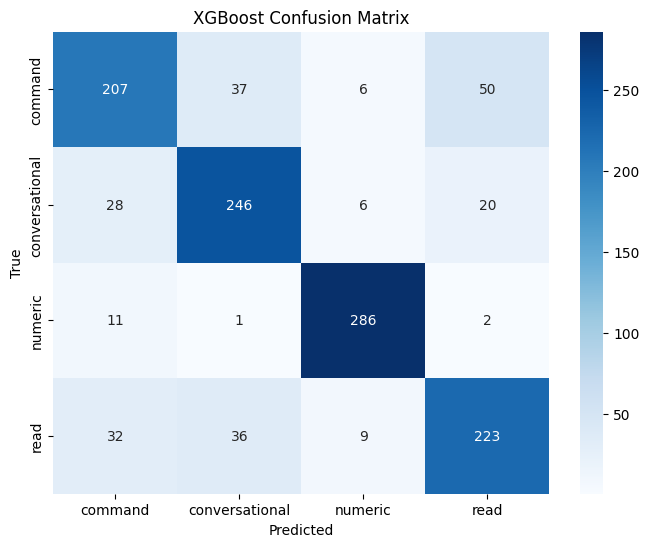

In [ ]:
cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("XGBoost Confusion Matrix")

plt.show()

Best Model Evaluation
Accuracy           : 0.8017
Precision (Macro)  : 0.8002
Recall (Macro)     : 0.8017
F1 Score           : 0.8004
ROC-AUC            : 0.9487
Macro F1           : 0.8004
Equal Error Rate   : 0.1171


<Figure size 600x500 with 0 Axes>

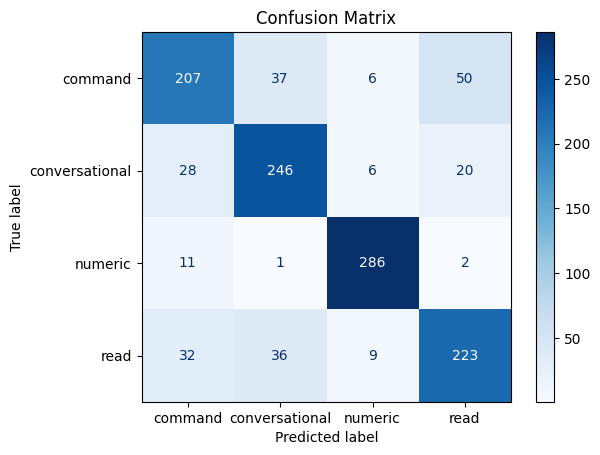

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# -----------------------------
# Metrics
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

macro_f1 = f1

# -----------------------------
# ROC-AUC
# -----------------------------
classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# -----------------------------
# Equal Error Rate (EER)
# -----------------------------
eer_list = []

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    fnr = 1 - tpr

    idx = np.nanargmin(np.abs(fpr - fnr))

    eer = (fpr[idx] + fnr[idx]) / 2

    eer_list.append(eer)

eer = np.mean(eer_list)

# -----------------------------
# Print Metrics
# -----------------------------
print("="*45)
print("Best Model Evaluation")
print("="*45)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision:.4f}")
print(f"Recall (Macro)     : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Equal Error Rate   : {eer:.4f}")

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

# Mfcc+Delta+Delta-Delta

In [ ]:
# Keep only MFCC, Delta MFCC and Delta-Delta MFCC features

feature_cols = [
    col for col in df.columns
    if col.startswith("mfcc_")
    or col.startswith("delta_")
    or col.startswith("delta2_")
]

df_mfcc_delta = df[feature_cols + ["target"]]

print(df_mfcc_delta.shape)

(12000, 79)


In [ ]:
X = df_mfcc_delta.drop(columns=["target"])
y = df_mfcc_delta["target"]

print(X.shape)
print(y.shape)

(12000, 78)
(12000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(9600, 78)
(1200, 78)
(1200, 78)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=4,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=4, ...)

In [ ]:
from sklearn.metrics import accuracy_score

train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

print("Train Accuracy      :", accuracy_score(y_train, train_pred))
print("Validation Accuracy :", accuracy_score(y_val, val_pred))
print("Test Accuracy       :", accuracy_score(y_test, test_pred))

Train Accuracy      : 0.9966666666666667
Validation Accuracy : 0.7975
Test Accuracy       : 0.8141666666666667
